In [ ]:
pip install wget

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=58bfa0e1be40562f6a5caac7ef26e95ce4c369e84e9a929978024c1ebd87d1fa
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import wget
url="https://raw.githubusercontent.com/JohnCremona/ecdata/master/allcurves/allcurves.00000-09999"
filename=wget.download(url)
df = pd.read_csv(filename, sep='\s+', header=None)
df.head()
#from sage.all import EllipticCurve, prime_range



<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2938722307.py:7: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(filename, sep='\s+', header=None)


Saving output2.csv to output2.csv


,0,1,2,3,4,5
0,11,a,1,"[0,-1,1,-10,-20]",0,5
1,11,a,2,"[0,-1,1,-7820,-263580]",0,1
2,11,a,3,"[0,-1,1,0,0]",0,5
3,14,a,1,"[1,0,1,4,-6]",0,6
4,14,a,2,"[1,0,1,-36,-70]",0,6


In [ ]:
df.to_csv("elliptic_curves.csv", index=False)
print("Saved elliptic_curves.csv")

Saved elliptic_curves.csv


In [ ]:
import pandas as pd
df2 = pd.read_csv("output2.csv")

In [ ]:
df2.head()

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
0,2450,h,1,"[1,0,1,-1251,639398]",0,1,-1,-2,0,0,...,-64,-6,-55,0,18,-54,17,10,12,48
1,7730,k,1,"[1,0,0,-1960,-31400]",1,1,1,1,1,0,...,-39,24,8,-28,24,42,14,60,-48,26
2,4634,a,1,"[1,0,1,-214,-1356]",1,2,-1,-2,4,-1,...,36,-20,28,-42,60,24,38,66,42,18
3,4800,cl,2,"[0,1,0,-3393,74943]",0,2,0,1,0,2,...,-36,4,52,-12,-12,-6,-18,6,18,16
4,9078,d,1,"[1,0,1,-332,650]",1,2,-1,1,-2,2,...,6,36,-42,0,-12,26,58,-18,52,-24


In [ ]:
y=df2["4"]
print(y)

0       0
1       1
2       1
3       0
4       1
       ..
4995    1
4996    1
4997    1
4998    0
4999    0
Name: 4, Length: 5000, dtype: int64


In [ ]:
a_p=[str(i) for i in range(6, 206)]
X=df2[a_p]
X.head()

,6,7,8,9,10,11,12,13,14,15,...,196,197,198,199,200,201,202,203,204,205
0,-1,-2,0,0,3,5,6,1,-3,-6,...,-64,-6,-55,0,18,-54,17,10,12,48
1,1,1,1,0,2,-7,-7,3,6,-1,...,-39,24,8,-28,24,42,14,60,-48,26
2,-1,-2,4,-1,4,-6,2,-4,0,2,...,36,-20,28,-42,60,24,38,66,42,18
3,0,1,0,2,2,6,-2,0,-4,0,...,-36,4,52,-12,-12,-6,-18,6,18,16
4,-1,1,-2,2,-4,4,1,2,-2,-6,...,6,36,-42,0,-12,26,58,-18,52,-24


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
print(X_train)
len(X_train)

      6  7  8  9  10  11  12  13  14  15  ...  196  197  198  199  200  201  \
3820 -1 -1  0  4   0   2  -4  -6  -6   0  ...    4  -44  -20   40   12  -22   
2616  0  1  0 -4   3   1   6  -7   3   6  ...  -61    0  -34  -21   60   51   
3336  1  1  0 -4  -6   1  -4   2  -6 -10  ...   36   -4  -20    0   36  -20   
4640  0 -1  1 -2  -2   2  -2   2  -2   6  ...  -38   24  -10   -2   24  -10   
302   1 -3  0 -3  -3   2   7  -8  -4  -1  ...   26  -13   59  -50   55   23   
...  .. .. .. ..  ..  ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ...   
2564  0  0  0  1   0   0   0  -8   0   0  ...   -7    0   11    0    0    0   
1314  0  2  2  1   1  -1  -1   0   0  -4  ...   14   51   65  -18   24   34   
3571 -1  0 -2 -4  -4   1  -2   0   0  10  ...   34  -28   52  -50  -36   30   
2530 -1 -2  1  2   0  -4   0   8   0   6  ...  -34  -42   68   -6   12   54   
2015 -1 -1 -1  0  -1  -3  -1  -3   6   8  ...   42  -64   40  -53  -17   45   

      202  203  204  205  
3820  -14   50   48   20

4000

In [ ]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
Y_pred=logreg.predict(X_test)

In [ ]:
accuracy=accuracy_score(Y_pred,Y_test)
print(accuracy)
print("\nConfusion matrix:\n", confusion_matrix(Y_test, Y_pred))

0.96

Confusion matrix:
 [[460   9   0]
 [ 27 467   1]
 [  0   3  33]]


# graph the data

In [ ]:
rankzerocurves=df2[df2["4"]==0]

In [ ]:
rankzerocurves.head()

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
0,2450,h,1,"[1,0,1,-1251,639398]",0,1,-1,-2,0,0,...,-64,-6,-55,0,18,-54,17,10,12,48
3,4800,cl,2,"[0,1,0,-3393,74943]",0,2,0,1,0,2,...,-36,4,52,-12,-12,-6,-18,6,18,16
5,9030,g,1,"[1,1,0,-367,2149]",0,2,-1,-1,1,1,...,-50,-4,12,30,-12,-6,-46,46,-42,-48
10,5178,i,1,"[1,1,1,-766,7841]",0,1,1,-1,4,-2,...,34,-55,-30,-45,-47,-14,13,53,-24,-21
11,3885,k,2,"[1,0,1,-2237768,1288263683]",0,2,1,1,1,1,...,20,-10,26,-28,-18,-60,-42,34,20,-16


In [ ]:
print(len(rankzerocurves))

2371


In [ ]:
rankonecurves=df2[df2["4"]==1]

In [ ]:
rankonecurves.head()

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
1,7730,k,1,"[1,0,0,-1960,-31400]",1,1,1,1,1,0,...,-39,24,8,-28,24,42,14,60,-48,26
2,4634,a,1,"[1,0,1,-214,-1356]",1,2,-1,-2,4,-1,...,36,-20,28,-42,60,24,38,66,42,18
4,9078,d,1,"[1,0,1,-332,650]",1,2,-1,1,-2,2,...,6,36,-42,0,-12,26,58,-18,52,-24
6,1950,k,1,"[1,0,1,49,1298]",1,1,-1,1,0,1,...,-2,21,-40,-52,26,-13,-28,53,6,22
8,5208,i,1,"[0,-1,0,-499280,-290736372]",1,1,0,-1,1,-1,...,-58,54,42,12,0,-21,26,-40,44,-25


In [ ]:
ranktwocurves=df2[df2["4"]==2]

In [ ]:
ranktwocurves.head()

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
7,3940,a,1,"[0,-1,0,-6,1]",2,1,0,-1,-1,-4,...,-8,24,-22,53,33,-39,-13,-7,17,-6
9,2986,b,1,"[1,0,0,-17,169]",2,1,1,-2,-3,-4,...,31,-36,15,-55,-36,-38,8,-62,3,0
39,6986,a,1,"[1,-1,0,-5,17]",2,1,-1,0,-1,1,...,-14,19,-48,-42,-57,47,0,50,-18,61
40,5712,c,1,"[0,-1,0,16,144]",2,2,0,-1,-2,-1,...,30,-46,-60,-36,-18,38,-30,-48,62,-24
113,3842,b,2,"[1,0,0,-339,12769]",2,2,1,-2,-2,-4,...,2,-6,-16,-2,0,42,-14,-34,-2,-46


In [ ]:
print(len(ranktwocurves))

196


In [ ]:
averagea2r0=rankzerocurves["6"].mean()
print(averagea2r0)

0.04765921552087727


In [ ]:
rank0traces=[]
for i in range(6,206):
  rank0traces.append(rankzerocurves[str(i)].mean())


In [ ]:
print(rank0traces)

[np.float64(0.04765921552087727), np.float64(0.11008013496415014), np.float64(0.2526360185575706), np.float64(0.46857865879375793), np.float64(0.620413327709827), np.float64(0.5318431041754534), np.float64(0.6845212990299452), np.float64(0.8182201602699283), np.float64(0.7207929143821172), np.float64(0.8629270350063264), np.float64(1.0206663854913538), np.float64(0.9156474061577393), np.float64(1.154365246731337), np.float64(1.0978490088570223), np.float64(1.3205398566005904), np.float64(1.1345423871784057), np.float64(1.6326444538169549), np.float64(1.0552509489666808), np.float64(1.4137494727962885), np.float64(1.1037536904259806), np.float64(1.17798397300717), np.float64(0.9624630957401941), np.float64(1.4420075917334458), np.float64(0.728806410797132), np.float64(0.8717840573597638), np.float64(1.079291438211725), np.float64(0.9510754955714888), np.float64(1.6883171657528468), np.float64(0.8591311682834247), np.float64(1.2509489666807254), np.float64(1.2357654997891185), np.float64

In [ ]:
rank1traces=[]
for i in range(6,206):
  rank1traces.append(rankonecurves[str(i)].mean())

In [ ]:
print(rank1traces)

[np.float64(-0.01972872996300863), np.float64(-0.08672420879572544), np.float64(-0.16358405260994657), np.float64(-0.34648581997533906), np.float64(-0.4989724619810933), np.float64(-0.5018495684340321), np.float64(-0.4360871352240033), np.float64(-0.7127003699136868), np.float64(-0.6707768187422934), np.float64(-0.8610768598438142), np.float64(-0.6962597616111796), np.float64(-1.0468557336621456), np.float64(-0.917796958487464), np.float64(-0.9708179202630497), np.float64(-0.7879161528976573), np.float64(-1.172215371968763), np.float64(-0.998766954377312), np.float64(-1.2129058775174681), np.float64(-1.0513769009453349), np.float64(-1.332511302918208), np.float64(-1.1072749691738595), np.float64(-1.6115906288532675), np.float64(-1.0147965474722564), np.float64(-1.3806000822030415), np.float64(-1.718865598027127), np.float64(-1.2934648581997534), np.float64(-0.9716399506781751), np.float64(-0.8380600082203041), np.float64(-1.6785861076859845), np.float64(-1.2799013563501849), np.float64

In [ ]:
rank2traces=[]
for i in range(6,206):
  rank2traces.append(ranktwocurves[str(i)].mean())

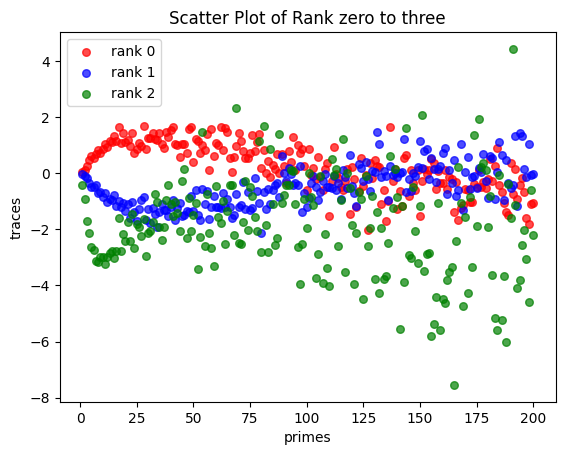

In [ ]:
import matplotlib.pyplot as plt
x = list(range(1, 201))
plt.scatter(x, rank0traces, color="red", s=30, alpha=0.7, label="rank 0" )
plt.scatter(x, rank1traces, color="blue", s=30, alpha=0.7, label="rank 1" )
plt.scatter(x, rank2traces, color="green", s=30, alpha=0.7, label="rank 2")
plt.xlabel("primes")
plt.ylabel("traces")
plt.title("Scatter Plot of Rank zero to three")
plt.legend()
plt.show()

In [ ]:
conductor=df2["0"]
print(conductor)

0       2450
1       7730
2       4634
3       4800
4       9078
        ... 
4995    1808
4996    6378
4997    2680
4998    4356
4999    7010
Name: 0, Length: 5000, dtype: int64


In [ ]:
lowest_1k  = conductor.nsmallest(1000)
highest_1k = conductor.nlargest(1000)


In [ ]:
sortrankzerocurves=rankzerocurves.sort_values(by="0")

In [ ]:
sortrankzerocurves.head(15)

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
3312,11,a,2,"[0,-1,1,-7820,-263580]",0,1,-2,-1,1,-2,...,-31,34,-3,-18,-12,-21,2,-41,-42,14
4738,14,a,1,"[1,0,1,4,-6]",0,6,-1,-2,0,1,...,2,-60,20,60,-12,66,14,26,-6,-24
446,15,a,3,"[1,1,1,-5,2]",0,8,-1,-1,1,0,...,34,-28,-12,-34,12,-38,-14,-18,18,16
868,24,a,2,"[0,-1,0,-24,-36]",0,4,0,-1,-2,0,...,-62,-12,-20,22,-36,-22,-14,46,2,24
228,26,a,2,"[1,0,1,-460,-3830]",0,1,-1,1,-3,-1,...,29,36,65,-30,-3,-54,-40,44,48,-54
2087,33,a,1,"[1,1,0,-11,0]",0,4,1,-1,-2,4,...,-46,-44,12,-42,-60,-54,2,-2,30,56
2377,34,a,3,"[1,0,0,-103,-411]",0,2,1,-2,0,-4,...,-22,18,-28,-18,30,18,26,44,-30,-48
33,42,a,1,"[1,1,1,-4,5]",0,8,1,-1,-2,-1,...,34,12,-44,38,-60,-22,50,-50,-30,-24
368,45,a,6,"[1,-1,0,315,1066]",0,2,1,0,-1,0,...,34,28,-12,34,-12,38,-14,-18,-18,-16
1754,48,a,4,"[0,1,0,1,0]",0,2,0,1,-2,0,...,-62,12,20,22,36,-22,-14,46,2,-24


In [ ]:
lowest_1kr0=sortrankzerocurves.head(1000)
largest_1kr0=sortrankzerocurves.tail(1000)
print(len(lowest_1kr0))
print(len(sortrankzerocurves))

1000
2371


In [ ]:
lowestrank0traces=[]
for i in range(6,206):
  lowestrank0traces.append(lowest_1kr0[str(i)].mean())

In [ ]:
largestrank0traces=[]
for i in range(6,206):
  largestrank0traces.append(largest_1kr0[str(i)].mean())

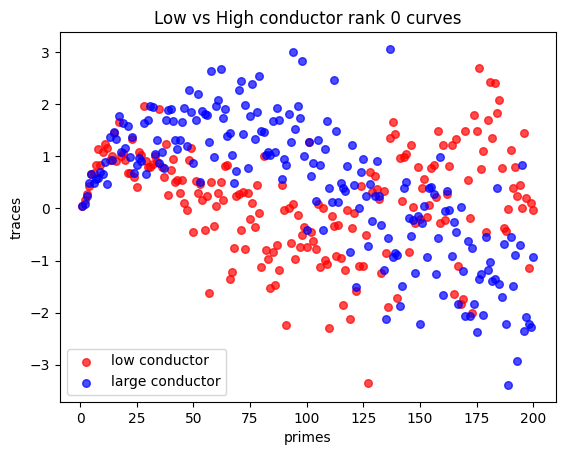

In [ ]:
import matplotlib.pyplot as plt
x = list(range(1, 201))
plt.scatter(x, lowestrank0traces, color="red", s=30, alpha=0.7, label="low conductor" )
plt.scatter(x, largestrank0traces, color="blue", s=30, alpha=0.7, label="large conductor" )
plt.xlabel("primes")
plt.ylabel("traces")
plt.title("Low vs High conductor rank 0 curves")
plt.legend()
plt.show()

In [ ]:
sortrankonecurves=rankonecurves.sort_values(by="0")

In [ ]:
lowest_1kr1=sortrankonecurves.head(1000)
largest_1kr1=sortrankonecurves.tail(1000)
lowestrank1traces=[]
for i in range(6,206):
  lowestrank1traces.append(lowest_1kr1[str(i)].mean())
largestrank1traces=[]
for i in range(6,206):
  largestrank1traces.append(largest_1kr1[str(i)].mean())

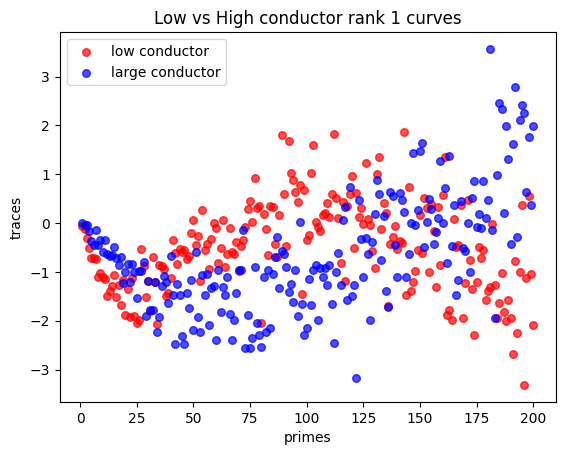

In [ ]:
import matplotlib.pyplot as plt
x = list(range(1, 201))
plt.scatter(x, lowestrank1traces, color="red", s=30, alpha=0.7, label="low conductor" )
plt.scatter(x, largestrank1traces, color="blue", s=30, alpha=0.7, label="large conductor" )
plt.xlabel("primes")
plt.ylabel("traces")
plt.title("Low vs High conductor rank 1 curves")
plt.legend()
plt.show()

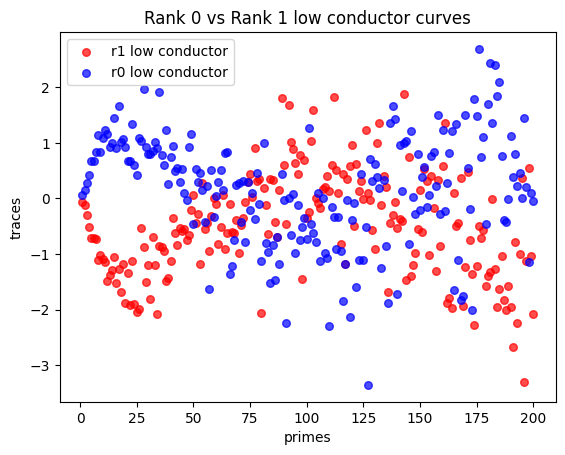

In [ ]:
import matplotlib.pyplot as plt
x = list(range(1, 201))
plt.scatter(x, lowestrank1traces, color="red", s=30, alpha=0.7, label="r1 low conductor" )
plt.scatter(x, lowestrank0traces, color="blue", s=30, alpha=0.7, label="r0 low conductor" )
plt.xlabel("primes")
plt.ylabel("traces")
plt.title("Rank 0 vs Rank 1 low conductor curves")
plt.legend()
plt.show()

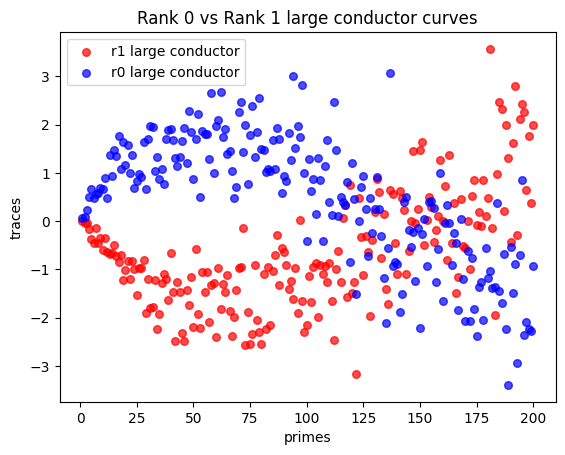

In [ ]:
import matplotlib.pyplot as plt
x = list(range(1, 201))
plt.scatter(x, largestrank1traces, color="red", s=30, alpha=0.7, label="r1 large conductor" )
plt.scatter(x, largestrank0traces, color="blue", s=30, alpha=0.7, label="r0 large conductor" )
plt.xlabel("primes")
plt.ylabel("traces")
plt.title("Rank 0 vs Rank 1 large conductor curves")
plt.legend()
plt.show()

In [ ]:
rank0conductor=rankzerocurves["0"]
rank1conductor=rankonecurves["0"]
largest_1kr0.tail(5)
largest_1kr1.tail(5)
largest_1kr0.head(5)

,0,1,2,3,4,5,6,7,8,9,...,196,197,198,199,200,201,202,203,204,205
312,5610,y,1,"[1,1,1,-1,-37]",0,2,1,-1,-1,4,...,56,44,-4,-38,36,12,-12,22,18,-24
2612,5610,x,1,"[1,1,1,-5389351,9273693149]",0,1,1,-1,-1,-1,...,11,-36,11,-63,1,52,58,-18,3,-29
3070,5610,b,1,"[1,1,0,27,-243]",0,1,-1,-1,-1,1,...,35,44,-25,57,-33,24,-58,-46,-23,-47
3101,5614,a,2,"[1,1,0,-8204,-287620]",0,2,-1,2,2,1,...,2,28,-36,38,28,6,-62,22,42,-24
3717,5616,t,1,"[0,0,0,-23787,849690]",0,1,0,0,-4,-1,...,-29,-9,65,2,-22,-24,-22,4,50,17


In [ ]:
merged_largest = pd.concat([largest_1kr0, largest_1kr1], ignore_index=True)
merged_largest.head()
y1=merged_largest["4"]
a_p=[str(i) for i in range(6, 206)]
X1=merged_largest[a_p]



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X1,y1,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy1=accuracy_score(Y_pred,Y_test)
print(accuracy1)

0.955


In [ ]:
merged_lowest = pd.concat([lowest_1kr0, lowest_1kr1], ignore_index=True)
merged_lowest.head()
y=merged_lowest["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_lowest[a_p]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy2=accuracy_score(Y_pred,Y_test)
print(accuracy2)

0.9875


In [ ]:
original=pd.concat([lowest_1kr0, lowest_1kr1, largest_1kr0, largest_1kr1], ignore_index=True)
y=original["4"]
a_p=[str(i) for i in range(6, 206)]
X=original[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy3=accuracy_score(Y_pred,Y_test)
print(accuracy3)


0.97875


In [ ]:
#make it merge 1000 rank 0 (200-1200) and the same for rank 1. (You are keeping 1000 conductor with mixed rank which is wrong)
r0_200_1200 = sortrankzerocurves.iloc[200:1201, :].copy()
r1_200_1200 = sortrankonecurves.iloc[200:1201, :].copy()
merged_200_1200 = pd.concat([r0_200_1200, r1_200_1200], ignore_index=True)
y=merged_200_1200["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_200_1200[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy4=accuracy_score(Y_pred,Y_test)
print(accuracy4)


0.9625935162094763


In [ ]:
r0_400_1400 = sortrankzerocurves.iloc[400:1401, :].copy()
r1_400_1400 = sortrankonecurves.iloc[400:1401, :].copy()
merged_400_1400 = pd.concat([r0_400_1400, r1_400_1400], ignore_index=True)
y=merged_400_1400["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_400_1400[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy5=accuracy_score(Y_pred,Y_test)
print(accuracy5)

0.9600997506234414


In [ ]:
r0_600_1600 = sortrankzerocurves.iloc[600:1601, :].copy()
r1_600_1600 = sortrankonecurves.iloc[600:1601, :].copy()
merged_600_1600 = pd.concat([r0_600_1600, r1_600_1600], ignore_index=True)
y=merged_600_1600["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_600_1600[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy6=accuracy_score(Y_pred,Y_test)
print(accuracy6)

0.972568578553616


In [ ]:
#do the 800 one
r0_800_1800 = sortrankzerocurves.iloc[800:1801, :].copy()
r1_800_1800 = sortrankonecurves.iloc[800:1801, :].copy()
merged_800_1800 = pd.concat([r0_800_1800, r1_800_1800], ignore_index=True)
y=merged_800_1800["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_800_1800[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy7=accuracy_score(Y_pred,Y_test)
print(accuracy7)

0.9376558603491272


In [ ]:
r0_1000_2000 = sortrankzerocurves.iloc[1200:2201, :].copy()
r1_1000_2000 = sortrankonecurves.iloc[1200:2201, :].copy()
merged_1000_2000 = pd.concat([r0_1000_2000, r1_1000_2000], ignore_index=True)
y=merged_1000_2000["4"]
a_p=[str(i) for i in range(6, 206)]
X=merged_1000_2000[a_p]
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X_train, X_test, Y_train, Y_test=train_test_split(X,y,test_size=.2)
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train,Y_train)
Y_pred=logreg.predict(X_test)
accuracy8=accuracy_score(Y_pred,Y_test)
print(accuracy8)


0.9451371571072319


In [ ]:
avg_low  = merged_lowest["0"].mean()
avg_high = merged_largest["0"].mean()
avg_middle1=merged_200_1200["0"].mean()
avg_middle2=merged_400_1400["0"].mean()
avg_middle3=merged_600_1600["0"].mean()
avg_middle4=merged_800_1800["0"].mean()
avg_middle5=merged_1000_2000["0"].mean()
X=[avg_low,avg_middle1,avg_middle2,avg_middle3,avg_middle4, avg_middle5,avg_high]
Y=[accuracy2,accuracy4,accuracy5,accuracy6,accuracy7,accuracy8,accuracy1]

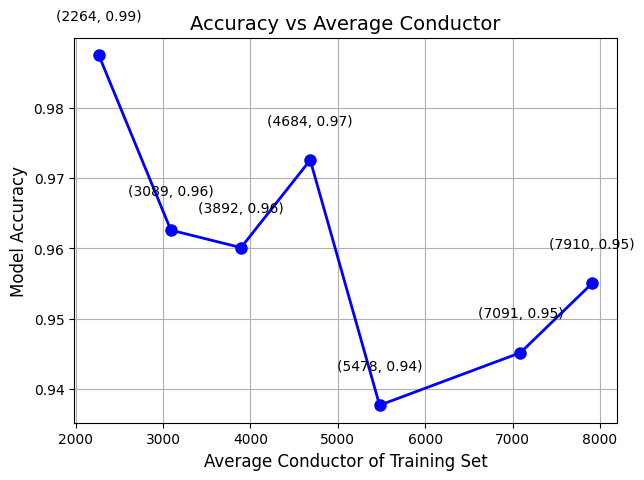

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(X, Y, 'o-', color='blue', markersize=8, linewidth=2)
plt.title("Accuracy vs Average Conductor", fontsize=14)
plt.xlabel("Average Conductor of Training Set", fontsize=12)
plt.ylabel("Model Accuracy", fontsize=12)
for i in range(len(X)):
    plt.text(X[i], Y[i]+0.005, f"({X[i]:.0f}, {Y[i]:.2f})", ha='center')

plt.grid(True)
plt.show()

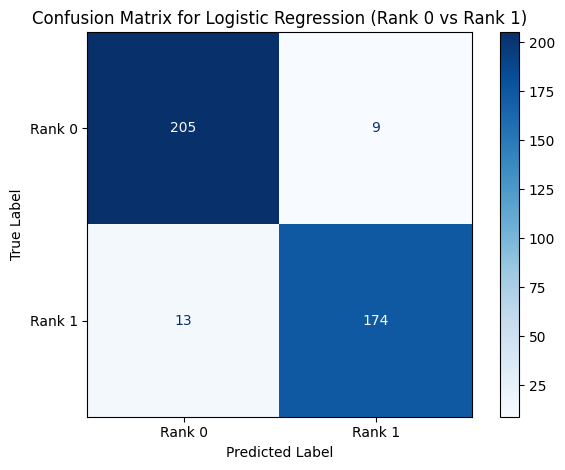

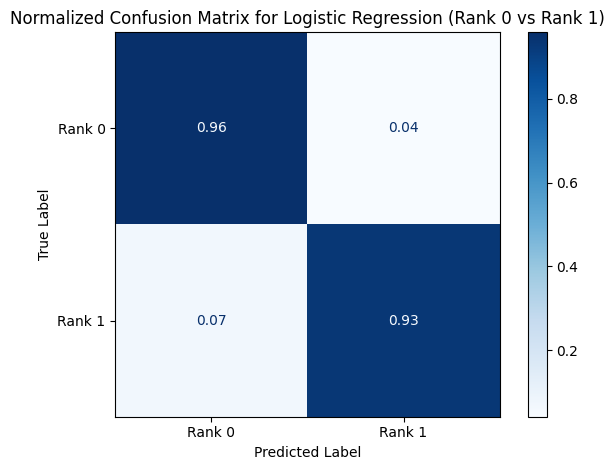

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix (raw counts)
cm = confusion_matrix(Y_test, Y_pred, labels=[0,1])

# Display raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Rank 0', 'Rank 1'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix for Logistic Regression (Rank 0 vs Rank 1)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_rank01.png", dpi=300)
plt.show()

# Compute and display normalized confusion matrix (percentages)
cm_norm = confusion_matrix(Y_test, Y_pred, labels=[0,1], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Rank 0', 'Rank 1'])
disp.plot(cmap='Blues', values_format='.2f')
plt.title("Normalized Confusion Matrix for Logistic Regression (Rank 0 vs Rank 1)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("confusion_matrix_rank01_normalized.png", dpi=300)
plt.show()